# **Style Guide**

**Colors**
- Border Color = #131428ff
- Background (Dashboard) = #141529ff
- Background (Plots + Blocks) = #252436ff
- Bar Chart Bars:
  - Violet: #554d85ff
  - Purple: #6e518bff
  - Blue: #4c74a3ff
  - Green: #4f772d
  - Yellow: #f4d35e
  - Red: #bc3908
- Emphasis Text Color (in blocks) = #fffcf2

Example: https://docs.google.com/drawings/d/1rF4MtWzITdDCPVMxGMDSZqO79pPfQozhB-Q75PWE_EQ/edit?usp=sharing

In [68]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import date


#connecting to AWS database instance
conn = psycopg2.connect(
        host='3.12.59.134',
        port=5432,
        database='foodsafety',
        user='postgres',
        password='Hamilton1776!',
        sslmode='require'
    )
print("Connected to PostgreSQL")

conn.autocommit = True
cursor = conn.cursor()

Connected to PostgreSQL


In [30]:
# Test Query

test_query = "SELECT COUNT(rid) FROM all_rest_data;"
df = pd.read_sql_query(test_query, conn, params=(True,))

df

C:\Users\milen\AppData\Local\Temp\ipykernel_12652\4082759782.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(test_query, conn, params=(True,))


,count
0,49199


# **Summary Statistics**

In [31]:
# creating a main summary stats dataframe:

# fid, date last inspected, num critical and non-critical violation
grab_facility_summary = '''SELECT
                        f.fid,
                        f.last_inspected as date,
                        fr.num_crit_not_corrected as critical,
                        fr.num_not_critical as non_critical,
                        fr.violation_count as total
                    FROM
                        facilities f
                        JOIN frequencies fr ON f.fid = fr.fid;'''

grab_violation_summary = '''
                            SELECT
                                v.fid,
                                v.violation_code as code,
                                v.inspection_type as type
                            FROM
                                violation_details v;
                        '''
                
facil_summary = pd.read_sql_query(grab_facility_summary, conn, params = (True,))
violation_summary = pd.read_sql_query(grab_violation_summary, conn, params=(True,))

#facil_summary.info()
#violation_summary.info()

# Converting date parameter to correct format
facil_summary['date'] = pd.to_datetime(facil_summary['date'], format='%Y-%m-%d').dt.date
facil_summary.head()

C:\Users\milen\AppData\Local\Temp\ipykernel_12652\4149404811.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  facil_summary = pd.read_sql_query(grab_facility_summary, conn, params = (True,))
C:\Users\milen\AppData\Local\Temp\ipykernel_12652\4149404811.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  violation_summary = pd.read_sql_query(grab_violation_summary, conn, params=(True,))


,fid,date,critical,non_critical,total
0,f77d0de8-9998-484a-862a-458d96228de7,2024-09-19,0,0,0
1,91181f3e-41c0-40ef-8810-b76fb5170a8a,2025-09-19,0,2,0
2,878a5497-8c2b-4ae7-80f9-beb349cf9542,2026-02-05,0,2,0
3,7fa94931-7df6-4a76-8675-4e47c8d965c6,2026-02-04,0,2,0
4,906b0609-a3c9-42f1-ac0d-24d51eb7eea7,2025-11-13,0,3,0


In [34]:
# Numerical Summary Statistics:

# Finding Number of Facilities in database:
number_of_facilites = len(facil_summary)

# Most Recent Inspection Date:
recent_date = facil_summary['date'].max()

# Average Number of Violations
avg_violations = facil_summary['total'].mean()

# Median Number of Total Violations:
median_violations = facil_summary['total'].median()

# Printing Out Results:
print("Number of Facilities in Database:", number_of_facilites)
print("Most Recent Inspection Date in Database:", recent_date)
print("Average Number of Violations for Facilities in Database:", avg_violations)
print("Median Number of Violations for Facilities in Database:", median_violations)

Number of Facilities in Database: 21699
Most Recent Inspection Date in Database: 2026-02-06
Average Number of Violations for Facilities in Database: 0.19332688142310706
Median Number of Violations for Facilities in Database: 0.0


Mean and median do not appear to be great metrics for this model-- they don't show much that would be helpful.

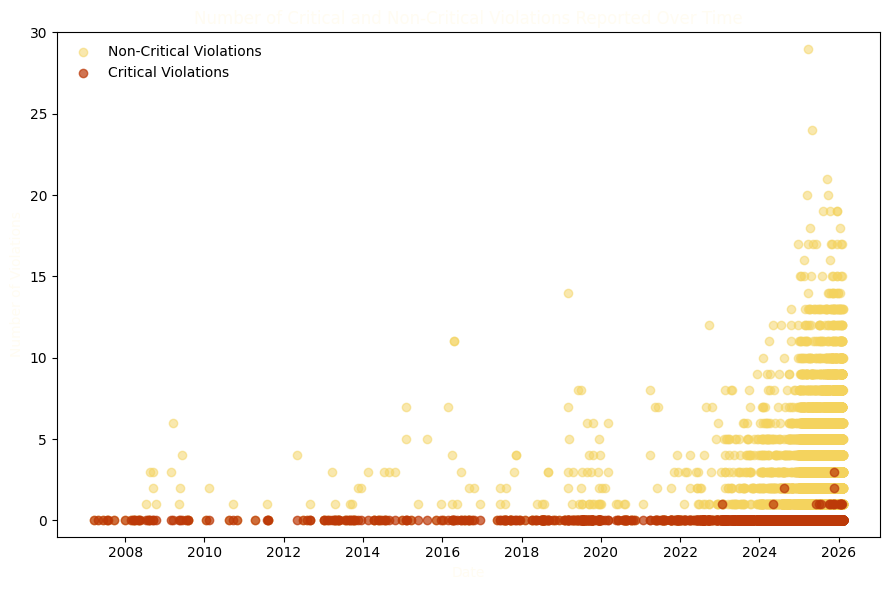

In [74]:
# Scatter Plot for number violations found by date
fig, ax = plt.subplots(figsize=(9,6))

plt.scatter(facil_summary['date'], facil_summary['non_critical'], label='Non-Critical Violations', alpha = 0.5,
    color = '#f4d35e')
plt.scatter(facil_summary['date'], facil_summary['critical'], label='Critical Violations', alpha=0.7,
    color = '#bc3908')

plt.xlabel("Date", color='#fffcf2')
plt.ylabel("Number of Violations", color='#fffcf2')
plt.title("Number of Critical and Non-Critical Violations Reported Over Time", color='#fffcf2')
leg = plt.legend()
plt.legend(frameon=False)
#plt.xlim(pd.to_datetime("2026-01-01"), date.today())
plt.ylim(-1, 30)

plt.tight_layout()
plt.show()
